# Noções e Proposições Primitivas

**Módulo:** 04 – Geometria Plana

**Pré-requisitos:** [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb) (variáveis, tipos básicos, funções e primeiros gráficos com `matplotlib`). Nenhum outro notebook do módulo 04 é necessário — este é o ponto de entrada da Geometria Plana.

**Objetivos de aprendizagem:** ao final você será capaz de...
- Diferenciar noção primitiva de proposição primitiva (postulado) e explicar por que todo sistema lógico precisa de um ponto de partida que não é demonstrado.
- Reconhecer ponto, reta e plano como entes primitivos e representá-los com a notação geométrica padrão.
- Enunciar os postulados de existência e de determinação da reta e do plano.
- Usar Python para visualizar pontos, retas, semirretas e planos, ligando a ideia de "primitivo" também à programação.

**Tempo estimado:** 45 a 60 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/04_geometria_plana/0401a_nocoes_e_proposicoes_primitivas.ipynb)

## O jogo do dicionário

Pegue um dicionário e procure a palavra **linha**. Você vai encontrar algo como *"sucessão contínua de pontos"*.

Justo. Mas o que é **ponto**? O dicionário responde: *"lugar exato no espaço, sem dimensão"*.

E o que é **dimensão**? *"Extensão de algo em uma direção"*. E **extensão**? *"O espaço que uma linha ocupa"*...

Epa. Voltamos para **linha**, a palavra do começo. 🔁

Isso não é defeito daquele dicionário: acontece com **qualquer** dicionário. Toda definição usa outras palavras, que também precisariam ser definidas, que usam outras palavras... Ou a corrente anda em círculo, ou nunca termina.

A única saída é **parar em algum lugar**: escolher algumas ideias como ponto de partida, aceitas sem definição, e construir todo o resto em cima delas. A Matemática faz exatamente isso, e na geometria esses pontos de partida têm nome: **ponto, reta e plano**.

Neste notebook você vai ver quais são esses pontos de partida e quais regras básicas eles seguem. Toda a geometria que vem depois (triângulos, círculos, áreas, trigonometria) é construída em cima deles.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def pontas_na_janela(p1, p2, lo: float, hi: float) -> tuple:
    """Devolve os dois pontos onde a reta que passa por p1 e p2 sai da janela quadrada [lo, hi]."""
    p = np.array(p1, dtype=float)
    u = np.array(p2, dtype=float) - p
    t_entrada, t_saida = -np.inf, np.inf
    for k in range(2):
        if abs(u[k]) > 1e-12:
            t0, t1 = (lo - p[k]) / u[k], (hi - p[k]) / u[k]
            t_entrada = max(t_entrada, min(t0, t1))
            t_saida = min(t_saida, max(t0, t1))
    return p + t_entrada * u, p + t_saida * u


def desenhar_reta(ax, p1, p2, cor: str = COR_PONTO, lo: float = -6, hi: float = 6, largura: float = 2) -> None:
    """Desenha a reta por p1 e p2 de borda a borda da janela, com setas nas duas pontas (a reta não acaba)."""
    inicio, fim = pontas_na_janela(p1, p2, lo + 0.3, hi - 0.3)
    ax.annotate(
        "", xy=fim, xytext=inicio,
        arrowprops=dict(arrowstyle="<|-|>", color=cor, lw=largura, mutation_scale=16),
    )


def desenhar_ponto(ax, p, nome: str, cor: str = COR_AVISO, deslocamento=(0.2, 0.25)) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=8, zorder=5)
    ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=13, fontweight="bold")

Vamos jogar o jogo do dicionário em Python. Cada palavra aponta para a palavra-chave usada na sua definição, e o código segue a corrente até perceber que está andando em círculo.

In [2]:
# Cada palavra -> (definição, palavra-chave usada na definição)
definicoes = {
    "linha": ("sucessão contínua de pontos", "ponto"),
    "ponto": ("lugar exato no espaço, sem dimensão", "dimensão"),
    "dimensão": ("extensão de algo em uma direção", "extensão"),
    "extensão": ("o espaço que uma linha ocupa", "linha"),
}

palavra = "linha"
ja_visitadas = []
while palavra not in ja_visitadas:
    ja_visitadas.append(palavra)
    definicao, proxima = definicoes[palavra]
    print(f"{palavra:>9} -> \"{definicao}\"  (mas o que é {proxima}?)")
    palavra = proxima

print(f"\n🔁 Voltamos para '{palavra}': a corrente de definições fechou um ciclo.")

    linha -> "sucessão contínua de pontos"  (mas o que é ponto?)
    ponto -> "lugar exato no espaço, sem dimensão"  (mas o que é dimensão?)
 dimensão -> "extensão de algo em uma direção"  (mas o que é extensão?)
 extensão -> "o espaço que uma linha ocupa"  (mas o que é linha?)

🔁 Voltamos para 'linha': a corrente de definições fechou um ciclo.


## 1. Sistema axiomático: de onde vêm as verdades da Matemática

O jogo do dicionário mostra um problema que a Matemática precisa resolver logo no começo: **não dá para definir tudo, nem para provar tudo**. Toda prova usa fatos que já foram provados, que usam outros fatos... Em algum lugar a corrente tem que começar.

A solução é organizar o conhecimento em camadas, como um prédio. Essa organização se chama **sistema axiomático**:

📌 **Noção primitiva:** um conceito aceito **sem definição**. Não se explica o que ele "é", apenas como se comporta. Na geometria: ponto, reta e plano.

📌 **Proposição primitiva (postulado ou axioma):** uma afirmação aceita como verdadeira **sem demonstração**. Exemplo: "por dois pontos distintos passa uma única reta".

📌 **Teorema:** uma afirmação que **é demonstrada**, usando apenas as noções primitivas, os postulados e teoremas já demonstrados antes.

Resumindo: noções primitivas são as **palavras** que não se definem, postulados são as **regras** que não se provam, e teoremas são tudo o que se **deduz** a partir delas.

**Axioma ou postulado?** Hoje as duas palavras são usadas praticamente como sinônimos. A diferença é histórica: na obra de Euclides, **axiomas** (ou "noções comuns") eram verdades gerais, válidas em qualquer ciência (como "o todo é maior que a parte"), enquanto **postulados** eram afirmações específicas da geometria (como "por dois pontos passa uma reta").

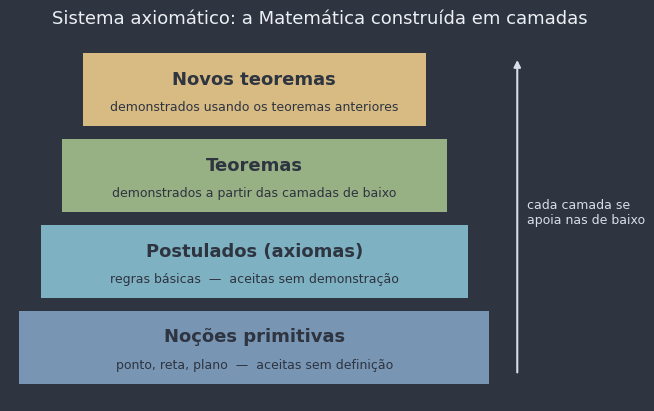

In [3]:
# O sistema axiomático como um prédio: cada andar se apoia nos de baixo
camadas = [
    ("Noções primitivas", "ponto, reta, plano  —  aceitas sem definição", COR_SECUNDARIA),
    ("Postulados (axiomas)", "regras básicas  —  aceitas sem demonstração", COR_PONTO),
    ("Teoremas", "demonstrados a partir das camadas de baixo", COR_DESTAQUE),
    ("Novos teoremas", "demonstrados usando os teoremas anteriores", COR_AVISO),
]

fig, ax = plt.subplots(figsize=(8, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)

for andar, (nome, descricao, cor) in enumerate(camadas):
    recuo = 0.45 * andar  # cada andar é um pouco mais estreito, como uma pirâmide
    ax.add_patch(plt.Rectangle((recuo, andar), 10 - 2 * recuo, 0.85, facecolor=cor, alpha=0.9))
    ax.text(5, andar + 0.55, nome, ha="center", va="center", color=NORD_FUNDO, fontsize=13, fontweight="bold")
    ax.text(5, andar + 0.22, descricao, ha="center", va="center", color=NORD_FUNDO, fontsize=9)

ax.annotate("", xy=(10.6, 3.8), xytext=(10.6, 0.1),
            arrowprops=dict(arrowstyle="-|>", color=NORD_TEXTO_SEC, lw=1.5))
ax.text(10.8, 2, "cada camada se\napoia nas de baixo", color=NORD_TEXTO_SEC, fontsize=9, va="center")

ax.set_xlim(-0.2, 13)
ax.set_ylim(-0.2, 4.1)
ax.axis("off")
ax.set_title("Sistema axiomático: a Matemática construída em camadas", color=NORD_TEXTO, fontsize=13)
plt.show()

🕵️ **Curiosidade histórica:** por volta de 300 a.C., em Alexandria, o matemático grego **Euclides** escreveu *Os Elementos*, uma coleção de 13 livros que organizou toda a geometria conhecida na época num único sistema axiomático: começava com 23 definições, 5 postulados e 5 noções comuns, e a partir deles demonstrava centenas de teoremas, um apoiado no outro. Foi o livro didático de geometria mais usado do mundo por mais de 2000 anos. É por isso que a geometria que você vai estudar neste módulo também é chamada de **geometria euclidiana**.

📖 **Leitura complementar:** [Euclides](https://pt.wikipedia.org/wiki/Euclides) · [Os Elementos](https://pt.wikipedia.org/wiki/Os_Elementos) · [Axioma](https://pt.wikipedia.org/wiki/Axioma)

🎯 **Aplicação prática — o Python também tem "primitivos":** a linguagem que você está usando funciona do mesmo jeito. Existem tipos **primitivos** (`int`, `float`, `str`, `bool`) que o Python já traz prontos, sem que você precise construí-los. Tudo o mais (listas, dicionários, funções, programas inteiros) é montado em cima deles, camada por camada. Veja uma "turma" desmontada até os primitivos:

In [4]:
# Camada 1: tipos primitivos, que o Python já traz prontos
nome = "Ana"         # str
idade = 15           # int
nota = 8.5           # float
aprovada = True      # bool

# Camada 2: um dicionário construído com primitivos
aluna = {"nome": nome, "idade": idade, "nota": nota, "aprovada": aprovada}

# Camada 3: uma lista construída com dicionários
turma = [aluna, {"nome": "Caio", "idade": 16, "nota": 6.0, "aprovada": False}]


def desmontar(objeto, nivel: int = 0) -> None:
    """Mostra de que tipos um objeto é feito, descendo até chegar nos tipos primitivos."""
    recuo = "    " * nivel
    if isinstance(objeto, list):
        print(f"{recuo}list (construída)")
        for item in objeto:
            desmontar(item, nivel + 1)
    elif isinstance(objeto, dict):
        print(f"{recuo}dict (construído)")
        for chave, valor in objeto.items():
            print(f"{recuo}    {chave!r}: {type(valor).__name__}  <- primitivo")
    else:
        print(f"{recuo}{type(objeto).__name__}  <- primitivo")


desmontar(turma)

list (construída)
    dict (construído)
        'nome': str  <- primitivo
        'idade': int  <- primitivo
        'nota': float  <- primitivo
        'aprovada': bool  <- primitivo
    dict (construído)
        'nome': str  <- primitivo
        'idade': int  <- primitivo
        'nota': float  <- primitivo
        'aprovada': bool  <- primitivo


Repare no paralelo: o Python não "explica" o que é um `int` em termos de algo mais simples. Ele simplesmente oferece o `int` com certas regras de funcionamento (dá para somar, comparar...). A geometria faz o mesmo com o ponto.

**Pergunta de checagem:** por que a Matemática não consegue definir absolutamente tudo? O que aconteceria se tentássemos?

**Pergunta de checagem:** qual é a diferença entre um postulado e um teorema? Se alguém te mostrar uma afirmação geométrica verdadeira, como você saberia em qual das duas categorias ela está?

## 2. Ponto, reta e plano: as três noções primitivas

A geometria plana começa com três ideias que **não são definidas**: o **ponto**, a **reta** e o **plano**. Em vez de defini-las, a gente descreve como elas se comportam e combina uma notação para escrevê-las:

| Ente primitivo | Ideia intuitiva | Notação | Exemplos |
|---|---|---|---|
| **Ponto** | marca uma posição; não tem tamanho, largura nem espessura | letra **maiúscula** latina | A, B, C, P |
| **Reta** | "linha" perfeitamente reta, sem espessura e **ilimitada nos dois sentidos** | letra **minúscula** latina, ou dois de seus pontos com seta dupla | r, s, t, ou $\overleftrightarrow{AB}$ |
| **Plano** | superfície perfeitamente lisa, sem espessura, que se estende **infinitamente em todas as direções** | letra **grega** minúscula, desenhada como um paralelogramo | α (alfa), β (beta), γ (gama) |

📌 **"Não definir" não é "não saber do que se trata".** Todo mundo tem uma ideia clara do que é um ponto ou uma reta; o que não existe é uma definição feita com palavras mais simples. A ideia é aceita intuitivamente, e o que **realmente** importa são as regras (os postulados) que esses entes obedecem, que você vai ver na seção 3.

Note que qualquer desenho é só uma **representação**: a bolinha que desenhamos para o ponto tem tamanho, a linha desenhada tem espessura e termina na borda do papel. Os entes geométricos de verdade não têm nenhuma dessas limitações.

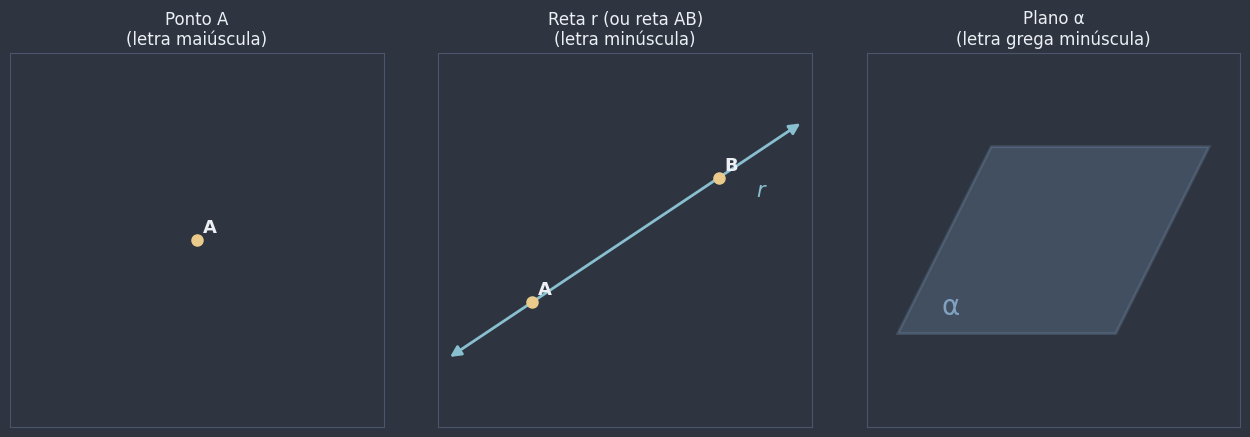

In [5]:
fig, eixos = plt.subplots(1, 3, figsize=(13, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
for ax in eixos:
    estilizar_eixo(ax)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

# Ponto: só uma posição
desenhar_ponto(eixos[0], (0, 0), "A")
eixos[0].set_title("Ponto A\n(letra maiúscula)", color=NORD_TEXTO, fontsize=12)

# Reta: as setas lembram que ela continua para sempre dos dois lados
desenhar_reta(eixos[1], (-3, -2), (3, 2))
desenhar_ponto(eixos[1], (-3, -2), "A")
desenhar_ponto(eixos[1], (3, 2), "B")
eixos[1].text(4.2, 1.4, "r", color=COR_PONTO, fontsize=15, fontstyle="italic")
eixos[1].set_title("Reta r (ou reta AB)\n(letra minúscula)", color=NORD_TEXTO, fontsize=12)

# Plano: desenhado como paralelogramo, mas se estende em todas as direções
vertices = np.array([[-5, -3], [2, -3], [5, 3], [-2, 3]])
eixos[2].add_patch(plt.Polygon(vertices, facecolor=COR_SECUNDARIA, alpha=0.25, edgecolor=COR_SECUNDARIA, lw=2))
eixos[2].text(-3.6, -2.4, "α", color=COR_SECUNDARIA, fontsize=20)
eixos[2].set_title("Plano α\n(letra grega minúscula)", color=NORD_TEXTO, fontsize=12)

plt.tight_layout()
plt.show()

**Quantos pontos cabem em uma reta?** Uma forma de pensar: entre dois pontos quaisquer de uma reta, sempre existe outro ponto no meio deles (o ponto médio). E entre esse novo ponto e o primeiro, existe outro. E outro... Sem fim. Vamos ver isso numericamente, marcando os pontos por um número na reta, com A = 0 e B = 1:

In [6]:
posicao_a = 0.0
posicao_b = 1.0

linhas = []
ultimo = posicao_b
for passo in range(1, 13):
    ponto_medio = (posicao_a + ultimo) / 2  # sempre há um ponto entre A e o último encontrado
    linhas.append({"passo": passo, "novo ponto entre A e o anterior": ponto_medio, "distância até A": ponto_medio - posicao_a})
    ultimo = ponto_medio

tabela_pontos_medios = pd.DataFrame(linhas)
display(tabela_pontos_medios.style.format({"novo ponto entre A e o anterior": "{:.6f}", "distância até A": "{:.6f}"}).hide(axis="index"))
print("A distância fica cada vez menor, mas nunca chega a zero: sempre cabe mais um ponto.")

passo,novo ponto entre A e o anterior,distância até A
1,0.500000,0.500000
2,0.250000,0.250000
3,0.125000,0.125000
4,0.062500,0.062500
5,0.031250,0.031250
6,0.015625,0.015625
7,0.007812,0.007812
8,0.003906,0.003906
9,0.001953,0.001953
10,0.000977,0.000977


A distância fica cada vez menor, mas nunca chega a zero: sempre cabe mais um ponto.


🕹️ **Widget interativo:** o ponto P anda sobre a reta r (mexa em `posição de P`). Depois aumente `pontos marcados`: com poucos pontos, dá para ver os espaços entre eles; com muitos, eles parecem virar uma linha contínua. A reta tem **infinitos** pontos, e nenhuma quantidade finita consegue preenchê-la.

In [7]:
def mostrar_ponto_na_reta(posicao: float, quantidade: int) -> None:
    fig, ax = plt.subplots(figsize=(6.5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    # reta r passando por (-4, -2) e (4, 2), ou seja, y = x/2
    desenhar_reta(ax, (-4, -2), (4, 2), cor=NORD_LINHA, largura=1.2)
    xs_marcados = np.linspace(-5.5, 5.5, quantidade)
    ax.plot(xs_marcados, xs_marcados / 2, "o", color=COR_PONTO, markersize=max(1.5, 7 - quantidade / 30))

    ponto_p = (posicao, posicao / 2)
    desenhar_ponto(ax, ponto_p, "P", cor=COR_AVISO)
    ax.text(5.1, 2.0, "r", color=COR_PONTO, fontsize=15, fontstyle="italic")

    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal")
    ax.set_title(f"P = ({ponto_p[0]:.1f}; {ponto_p[1]:.2f})  —  {quantidade} pontos marcados em r",
                 color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    mostrar_ponto_na_reta,
    posicao=widgets.FloatSlider(value=1.0, min=-5, max=5, step=0.1, description="posição de P:",
                                style={"description_width": "initial"}),
    quantidade=widgets.IntSlider(value=8, min=2, max=300, step=1, description="pontos marcados:",
                                 style={"description_width": "initial"}),
);

interactive(children=(FloatSlider(value=1.0, description='posição de P:', max=5.0, min=-5.0, style=SliderStyle…

⚠️ **Erro comum:** confundir **reta** com **segmento de reta**. A reta **não tem começo nem fim**: o traço que desenhamos no caderno é, na verdade, só um pedaço dela. Quando cortamos a reta com pontos, aparecem outros objetos, que ganham nomes próprios:

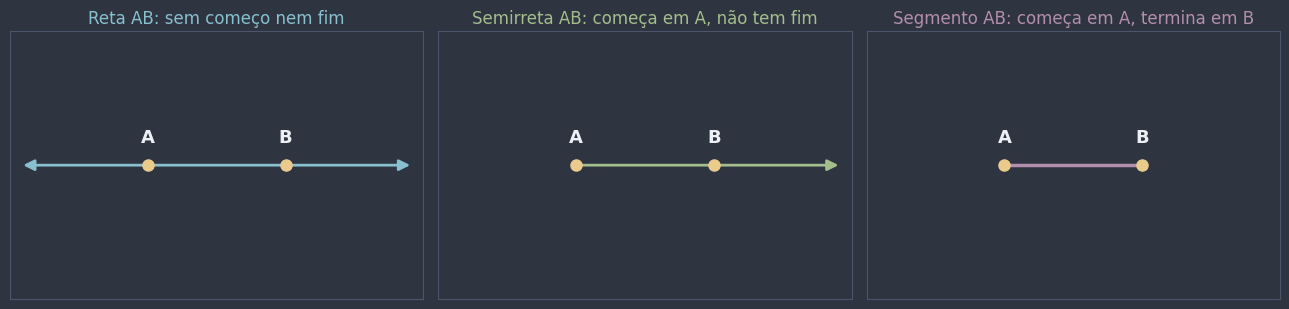

In [8]:
fig, eixos = plt.subplots(1, 3, figsize=(13, 3.2))
fig.patch.set_facecolor(NORD_FUNDO)
ponto_a, ponto_b = (-2, 0), (2, 0)

for ax in eixos:
    estilizar_eixo(ax)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-2, 2)
    ax.set_xticks([])
    ax.set_yticks([])

# Reta: setas nas duas pontas
desenhar_reta(eixos[0], ponto_a, ponto_b, cor=COR_PONTO)
eixos[0].set_title("Reta AB: sem começo nem fim", color=COR_PONTO, fontsize=12)

# Semirreta: começa em A e segue para sempre no sentido de B
eixos[1].annotate("", xy=(5.7, 0), xytext=ponto_a,
                  arrowprops=dict(arrowstyle="-|>", color=COR_DESTAQUE, lw=2, mutation_scale=16))
eixos[1].set_title("Semirreta AB: começa em A, não tem fim", color=COR_DESTAQUE, fontsize=12)

# Segmento: começa em A e termina em B
eixos[2].plot([ponto_a[0], ponto_b[0]], [ponto_a[1], ponto_b[1]], color=COR_EXTRA, lw=2.5)
eixos[2].set_title("Segmento AB: começa em A, termina em B", color=COR_EXTRA, fontsize=12)

for ax in eixos:
    desenhar_ponto(ax, ponto_a, "A", deslocamento=(-0.2, 0.35))
    desenhar_ponto(ax, ponto_b, "B", deslocamento=(-0.2, 0.35))

plt.tight_layout()
plt.show()

📎 **Conexão:** a **semirreta** (a reta cortada por um ponto, que vira sua origem) e o **segmento de reta** vão ser formalizados no próximo notebook do módulo, 📌 Segmento de reta (semirretas, segmentos, medida e congruência). Por enquanto basta lembrar: só a reta é ilimitada nos dois sentidos.

🎯 **Aplicação prática — computação gráfica:** todo desenho numa tela é feito de **pixels**, pequenos quadradinhos que funcionam como os "pontos" da tela. Programas de desenho e jogos usam pontos e retas como **primitivas de renderização**: para desenhar uma reta, o computador decide quais pixels acender entre as duas pontas. Como pixels têm tamanho, a reta "ideal" vira uma escadinha:

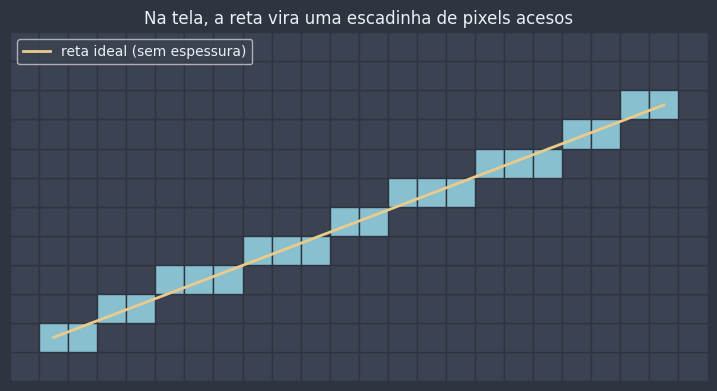

In [9]:
largura_tela, altura_tela = 24, 12
inicio_linha, fim_linha = (1, 1), (22, 9)

fig, ax = plt.subplots(figsize=(9, 4.8))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)

# Grade de pixels apagados
for i in range(largura_tela):
    for j in range(altura_tela):
        ax.add_patch(plt.Rectangle((i, j), 1, 1, facecolor=NORD_PAINEL, edgecolor=NORD_FUNDO, lw=1))

# Para cada coluna de pixels, acende o pixel mais próximo da reta ideal
inclinacao = (fim_linha[1] - inicio_linha[1]) / (fim_linha[0] - inicio_linha[0])
for coluna in range(inicio_linha[0], fim_linha[0] + 1):
    linha_pixel = round(inicio_linha[1] + inclinacao * (coluna - inicio_linha[0]))
    ax.add_patch(plt.Rectangle((coluna, linha_pixel), 1, 1, facecolor=COR_PONTO, edgecolor=NORD_FUNDO, lw=1))

# Reta ideal, passando pelo centro dos pixels das pontas
ax.plot([inicio_linha[0] + 0.5, fim_linha[0] + 0.5], [inicio_linha[1] + 0.5, fim_linha[1] + 0.5],
        color=COR_AVISO, lw=2, label="reta ideal (sem espessura)")

ax.set_xlim(0, largura_tela)
ax.set_ylim(0, altura_tela)
ax.set_aspect("equal")
ax.axis("off")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper left")
ax.set_title("Na tela, a reta vira uma escadinha de pixels acesos", color=NORD_TEXTO, fontsize=12)
plt.show()

**Pergunta de checagem:** quantos pontos cabem em uma reta? E em um segmento bem pequeno dessa mesma reta, com 1 milímetro de comprimento? (Dica: a tabela dos pontos médios começou com um segmento de A = 0 até B = 1.)

**Pergunta de checagem:** na notação padrão, o que representam "P", "s" e "β"?

## 3. Proposições primitivas: postulados de existência e determinação

Agora que temos as "palavras" (ponto, reta, plano), precisamos das "regras do jogo": os **postulados**, afirmações sobre esses entes que aceitamos sem demonstração. Eles são as primeiras verdades da geometria, e todo o resto será deduzido a partir deles.

### 3.1 Postulado de existência

📌 **Postulado de existência:**
- Numa reta, bem como fora dela, existem **infinitos pontos**.
- Num plano, bem como fora dele, existem **infinitos pontos**.

Parece óbvio, e é para parecer! Um postulado costuma ser uma afirmação tão básica que todo mundo concorda com ela. Mas ela precisa estar escrita: sem ela, nada garantiria que existe um ponto fora de uma reta para, por exemplo, construir um triângulo.

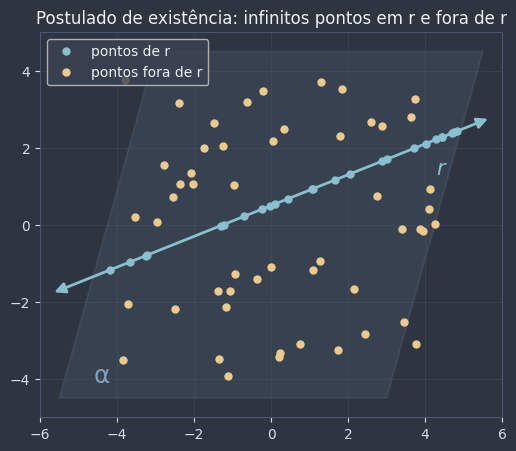

In [10]:
gerador = np.random.default_rng(seed=4)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

# Plano α (o paralelogramo representa só um pedaço dele)
vertices_alfa = np.array([[-5.5, -4.5], [3, -4.5], [5.5, 4.5], [-3, 4.5]])
ax.add_patch(plt.Polygon(vertices_alfa, facecolor=COR_SECUNDARIA, alpha=0.12, edgecolor=COR_SECUNDARIA, lw=1.5))
ax.text(-4.6, -4.1, "α", color=COR_SECUNDARIA, fontsize=18)

# Reta r: y = 0.4x + 0.5
desenhar_reta(ax, (-4, -1.1), (4, 2.1), cor=COR_PONTO)
ax.text(4.3, 1.3, "r", color=COR_PONTO, fontsize=15, fontstyle="italic")

# Alguns dos infinitos pontos de r...
xs_em_r = gerador.uniform(-5, 5, 25)
ax.plot(xs_em_r, 0.4 * xs_em_r + 0.5, "o", color=COR_PONTO, markersize=5, label="pontos de r")

# ...e alguns dos infinitos pontos fora de r
fora_x = gerador.uniform(-4.5, 4.5, 60)
fora_y = gerador.uniform(-4, 4, 60)
longe_de_r = np.abs(fora_y - (0.4 * fora_x + 0.5)) > 0.6
ax.plot(fora_x[longe_de_r], fora_y[longe_de_r], "o", color=COR_AVISO, markersize=5, label="pontos fora de r")

ax.set_xlim(-6, 6)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, loc="upper left")
ax.set_title("Postulado de existência: infinitos pontos em r e fora de r", color=NORD_TEXTO, fontsize=12)
plt.show()

### 3.2 Postulado de determinação da reta

📌 **Postulado de determinação da reta:** dois pontos **distintos** determinam uma **única** reta que passa por eles.

"Determinar" tem duas partes aqui:
- **Existência:** sempre há uma reta passando pelos dois pontos.
- **Unicidade:** essa reta é **só uma**. Não existe uma segunda reta, diferente da primeira, que passe pelos mesmos dois pontos.

Por isso, a reta que passa por A e B pode ser chamada simplesmente de "reta AB" ($\overleftrightarrow{AB}$): o nome não é ambíguo, porque só existe uma.

Veja a diferença entre **curvas** e **retas**: por A e B passam infinitas curvas, mas só uma reta.

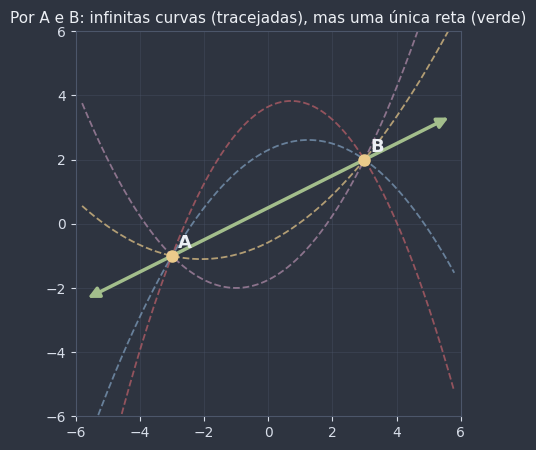

In [11]:
ponto_a = np.array([-3.0, -1.0])
ponto_b = np.array([3.0, 2.0])
inclinacao_ab = (ponto_b[1] - ponto_a[1]) / (ponto_b[0] - ponto_a[0])

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

xs = np.linspace(-5.8, 5.8, 300)
reta_ab = ponto_a[1] + inclinacao_ab * (xs - ponto_a[0])

# Curvas que também passam por A e B: somamos à reta um termo que zera em A e em B
for k, cor in zip([0.25, -0.2, 0.12, -0.35], [COR_EXTRA, COR_SECUNDARIA, COR_AVISO, COR_ALERTA]):
    curva = reta_ab + k * (xs - ponto_a[0]) * (xs - ponto_b[0])
    ax.plot(xs, curva, color=cor, lw=1.3, alpha=0.7, linestyle="--")

desenhar_reta(ax, ponto_a, ponto_b, cor=COR_DESTAQUE, largura=2.5)
desenhar_ponto(ax, ponto_a, "A")
desenhar_ponto(ax, ponto_b, "B")

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect("equal")
ax.set_title("Por A e B: infinitas curvas (tracejadas), mas uma única reta (verde)", color=NORD_TEXTO, fontsize=11)
plt.show()

Com coordenadas, dá para ver essa reta também de forma **algébrica**. Se você já estudou função afim, lembra que uma reta não vertical tem equação $y = ax + b$. A função abaixo calcula essa equação a partir de dois pontos e recusa o caso de pontos iguais, porque aí o postulado não se aplica:

In [12]:
def equacao_da_reta(p1: tuple[float, float], p2: tuple[float, float]) -> str:
    """Devolve a equação da única reta que passa por p1 e p2 (pontos distintos)."""
    (x1, y1), (x2, y2) = p1, p2
    if (x1, y1) == (x2, y2):
        raise ValueError("Os pontos são iguais: por um único ponto passam infinitas retas.")
    if x1 == x2:
        return f"x = {x1:g}  (reta vertical)"
    a = (y2 - y1) / (x2 - x1)
    b = y1 - a * x1
    return f"y = {a:g}x + {b:g}"


pares = [((0, 0), (1, 1)), ((-3, -1), (3, 2)), ((2, 5), (2, -1)), ((-1, 4), (3, 4)), ((1, 3), (4, -3))]
tabela_retas = pd.DataFrame(
    [{"ponto 1": p1, "ponto 2": p2, "reta determinada": equacao_da_reta(p1, p2)} for p1, p2 in pares]
)
display(tabela_retas.style.hide(axis="index"))

ponto 1,ponto 2,reta determinada
"(0, 0)","(1, 1)",y = 1x + 0
"(-3, -1)","(3, 2)",y = 0.5x + 0.5
"(2, 5)","(2, -1)",x = 2 (reta vertical)
"(-1, 4)","(3, 4)",y = 0x + 4
"(1, 3)","(4, -3)",y = -2x + 5


🕹️ **Widget interativo:** o ponto A está fixo em (−2, −1). Mova o ponto B com os sliders: para cada posição de B existe **uma, e só uma**, reta passando pelos dois. Agora tente colocar B exatamente em cima de A (x = −2, y = −1) e veja o que acontece com a unicidade.

In [13]:
ponto_fixo_a = (-2.0, -1.0)


def mostrar_reta_determinada(x_b: float, y_b: float) -> None:
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)

    if np.isclose(x_b, ponto_fixo_a[0]) and np.isclose(y_b, ponto_fixo_a[1]):
        # A = B: um ponto só não determina reta nenhuma, passam infinitas por ele
        for angulo in np.linspace(0, np.pi, 12, endpoint=False):
            direcao = (ponto_fixo_a[0] + np.cos(angulo), ponto_fixo_a[1] + np.sin(angulo))
            desenhar_reta(ax, ponto_fixo_a, direcao, cor=COR_ALERTA, largura=1)
        titulo, cor_titulo = "A = B: infinitas retas passam por um ponto só!", COR_ALERTA
    else:
        desenhar_reta(ax, ponto_fixo_a, (x_b, y_b), cor=COR_DESTAQUE)
        desenhar_ponto(ax, (x_b, y_b), "B", cor=COR_PONTO)
        titulo, cor_titulo = f"Reta AB:  {equacao_da_reta(ponto_fixo_a, (x_b, y_b))}", COR_DESTAQUE

    desenhar_ponto(ax, ponto_fixo_a, "A")
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect("equal")
    ax.set_title(titulo, color=cor_titulo, fontsize=12)
    plt.show()


widgets.interact(
    mostrar_reta_determinada,
    x_b=widgets.FloatSlider(value=3, min=-5, max=5, step=0.5, description="x de B:"),
    y_b=widgets.FloatSlider(value=2, min=-5, max=5, step=0.5, description="y de B:"),
);

interactive(children=(FloatSlider(value=3.0, description='x de B:', max=5.0, min=-5.0, step=0.5), FloatSlider(…

💡 **Dica:** é esse postulado que garante que dois pregos numa parede sempre podem ser ligados por um fio bem esticado, e de um único jeito "reto". Pedreiros usam exatamente isso: esticam uma linha entre dois pregos para alinhar uma fileira de tijolos.

💡 **Dica — seu primeiro teorema:** do postulado de determinação já dá para **deduzir** uma afirmação nova: *duas retas distintas têm no máximo um ponto em comum.* Por quê? Se tivessem dois pontos em comum, esses dois pontos determinariam uma única reta, e as duas retas seriam a mesma, contradizendo o fato de serem distintas. Isso é um **teorema**: não foi aceito sem prova, foi demonstrado a partir de um postulado, exatamente como na pirâmide da seção 1.

🎯 **Aplicação prática — GPS e localização:** num mapa, dois pontos de referência (sua posição e o destino, cada um dado por coordenadas) determinam uma única rota em linha reta entre eles. É essa linha que o aplicativo usa para calcular a distância "em linha reta" e a direção para onde apontar a seta, antes de considerar ruas e curvas.

### 3.3 Postulado de determinação do plano

📌 **Pontos colineares:** pontos que pertencem a uma **mesma reta**. Dois pontos são sempre colineares (pelo postulado anterior, há uma reta passando por eles); com três ou mais, pode ser que sim, pode ser que não.

📌 **Postulado de determinação do plano:** três pontos **não colineares** determinam um **único** plano que passa por eles.

**Como saber, com coordenadas, se três pontos A, B e C são colineares?** Se estão na mesma reta, a "inclinação" de A até B é igual à de A até C:

$$\frac{y_B - y_A}{x_B - x_A} = \frac{y_C - y_A}{x_C - x_A}$$

Para não dividir por zero (reta vertical), multiplicamos cruzado e testamos se esta diferença dá zero:

$$(x_B - x_A)(y_C - y_A) - (y_B - y_A)(x_C - x_A) = 0$$

In [14]:
def tres_pontos_colineares(ponto_a, ponto_b, ponto_c) -> bool:
    """Testa se três pontos do plano estão numa mesma reta (multiplicação cruzada das inclinações)."""
    (xa, ya), (xb, yb), (xc, yc) = ponto_a, ponto_b, ponto_c
    return math.isclose((xb - xa) * (yc - ya) - (yb - ya) * (xc - xa), 0, abs_tol=1e-9)


print(tres_pontos_colineares((0, 0), (1, 2), (3, 6)))    # na reta y = 2x
print(tres_pontos_colineares((0, 0), (1, 2), (3, 5)))    # C fora da reta
print(tres_pontos_colineares((4, 1), (4, 7), (4, -2)))   # reta vertical x = 4

True
False
True


Por que a exigência de "não colineares"? Veja em 3D: à esquerda, três pontos não colineares e o único plano que passa por eles. À direita, três pontos **colineares**: eles não "travam" plano nenhum, e infinitos planos passam por eles, girando em volta da reta como as páginas de um livro aberto.

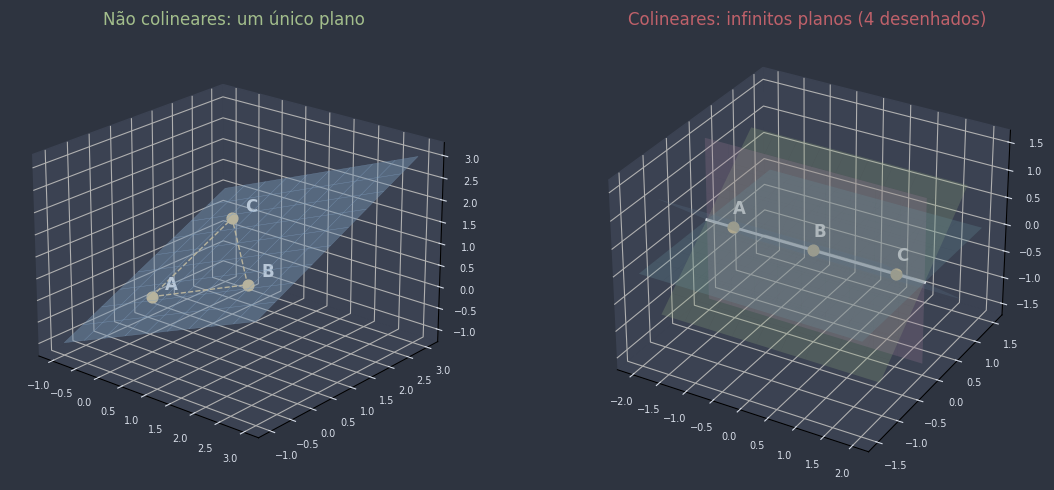

In [15]:
def estilizar_eixo_3d(ax) -> None:
    """Estilo Nord para eixos 3D (o estilizar_eixo padrão é para gráficos 2D)."""
    ax.set_facecolor(NORD_FUNDO)
    for eixo in (ax.xaxis, ax.yaxis, ax.zaxis):
        eixo.set_pane_color(NORD_PAINEL)
        eixo.label.set_color(NORD_TEXTO_SEC)
    ax.tick_params(colors=NORD_TEXTO_SEC, labelsize=7)


fig = plt.figure(figsize=(12, 5))
fig.patch.set_facecolor(NORD_FUNDO)

# Esquerda: A, B, C não colineares -> um único plano
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
estilizar_eixo_3d(ax1)
pontos_nc = np.array([[0, 0, 0], [2, 0, 1], [0, 2, 1]], dtype=float)
normal = np.cross(pontos_nc[1] - pontos_nc[0], pontos_nc[2] - pontos_nc[0])
grade_x, grade_y = np.meshgrid(np.linspace(-1, 3, 10), np.linspace(-1, 3, 10))
grade_z = pontos_nc[0, 2] - (normal[0] * (grade_x - pontos_nc[0, 0]) + normal[1] * (grade_y - pontos_nc[0, 1])) / normal[2]
ax1.plot_surface(grade_x, grade_y, grade_z, color=COR_SECUNDARIA, alpha=0.45, edgecolor=COR_SECUNDARIA, linewidth=0.3)
ax1.plot(*np.vstack([pontos_nc, pontos_nc[:1]]).T, color=COR_AVISO, lw=1, linestyle="--")
ax1.view_init(elev=22, azim=-50)
ax1.scatter(*pontos_nc.T, color=COR_AVISO, s=60, depthshade=False)
for nome, p in zip("ABC", pontos_nc):
    ax1.text(*(p + 0.15), nome, color=NORD_TEXTO, fontsize=12, fontweight="bold")
ax1.set_title("Não colineares: um único plano", color=COR_DESTAQUE, fontsize=12)

# Direita: A, B, C colineares (no eixo x) -> vários planos contêm a mesma reta
ax2 = fig.add_subplot(1, 2, 2, projection="3d")
estilizar_eixo_3d(ax2)
pontos_col = np.array([[-1.5, 0, 0], [0, 0, 0], [1.5, 0, 0]])
param_x, param_s = np.meshgrid(np.linspace(-2, 2, 10), np.linspace(-1.5, 1.5, 10))
for angulo, cor in zip([0, 45, 90, 135], [COR_PONTO, COR_DESTAQUE, COR_EXTRA, COR_SECUNDARIA]):
    theta = np.radians(angulo)
    ax2.plot_surface(param_x, param_s * np.cos(theta), param_s * np.sin(theta), color=cor, alpha=0.25)
ax2.plot([-2, 2], [0, 0], [0, 0], color=NORD_TEXTO, lw=2)
ax2.scatter(*pontos_col.T, color=COR_AVISO, s=60, depthshade=False)
for nome, p in zip("ABC", pontos_col):
    ax2.text(p[0], p[1], p[2] + 0.25, nome, color=NORD_TEXTO, fontsize=12, fontweight="bold")
ax2.set_title("Colineares: infinitos planos (4 desenhados)", color=COR_ALERTA, fontsize=12)

plt.tight_layout()
plt.show()

🕹️ **Widget interativo:** A, B e C estão numa mesma reta (a linha branca). Gire o plano com o slider: em **toda** posição ele continua passando pelos três pontos. Como há infinitos ângulos possíveis, há infinitos planos, e os três pontos colineares não determinam nenhum deles.

In [16]:
def girar_plano(angulo: float) -> None:
    fig = plt.figure(figsize=(6.5, 5.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax = fig.add_subplot(projection="3d")
    estilizar_eixo_3d(ax)

    theta = np.radians(angulo)
    ax.plot_surface(param_x, param_s * np.cos(theta), param_s * np.sin(theta), color=COR_PONTO, alpha=0.35)
    ax.plot([-2, 2], [0, 0], [0, 0], color=NORD_TEXTO, lw=2)
    ax.scatter(*pontos_col.T, color=COR_AVISO, s=60, depthshade=False)
    for nome, p in zip("ABC", pontos_col):
        ax.text(p[0], p[1], p[2] + 0.25, nome, color=NORD_TEXTO, fontsize=12, fontweight="bold")

    ax.set_xlim(-2, 2)
    ax.set_ylim(-1.6, 1.6)
    ax.set_zlim(-1.6, 1.6)
    ax.set_title(f"Plano girado {angulo:.0f}° em torno da reta: ainda contém A, B e C",
                 color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    girar_plano,
    angulo=widgets.FloatSlider(value=30, min=0, max=180, step=5, description="ângulo (°):"),
);

interactive(children=(FloatSlider(value=30.0, description='ângulo (°):', max=180.0, step=5.0), Output()), _dom…

🎯 **Aplicação prática — por que tripés não balançam:** câmeras, telescópios e banquinhos de ordenha usam **três pés**. As três pontas, se não estiverem alinhadas, determinam um único plano, então o apoio sempre "encaixa" no chão, mesmo que o chão seja irregular. Uma mesa de **quatro** pernas precisa que as quatro pontas estejam num mesmo plano; se uma perna for um pouquinho mais curta, a quarta ponta fica fora do plano das outras três e a mesa balança.

**Pergunta de checagem:** três pontos sempre determinam um plano único? Em que situação isso não vale?

**Pergunta de checagem:** quantas retas passam por um único ponto? E por dois pontos distintos?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Noção primitiva | conceito aceito **sem definição** (ponto, reta, plano) |
| Postulado (axioma) | afirmação aceita **sem demonstração** |
| Teorema | afirmação **demonstrada** a partir de noções primitivas, postulados e teoremas anteriores |
| Ponto | marca uma posição, sem dimensão; letra **maiúscula** (A, B, P) |
| Reta | ilimitada nos dois sentidos, sem espessura; letra **minúscula** (r, s) ou $\overleftrightarrow{AB}$ |
| Plano | superfície sem espessura, infinita em todas as direções; letra **grega** (α, β, γ) |
| Postulado de existência | numa reta, fora dela, num plano e fora dele existem **infinitos pontos** |
| Postulado de determinação da reta | dois pontos **distintos** → uma **única** reta |
| Postulado de determinação do plano | três pontos **não colineares** → um **único** plano |
| Pontos colineares | pontos que estão numa mesma reta; teste: $(x_B - x_A)(y_C - y_A) - (y_B - y_A)(x_C - x_A) = 0$ |
| Primeiro teorema | duas retas distintas têm **no máximo um** ponto em comum |

**A ideia central:** a geometria é um prédio. As noções primitivas são o terreno, os postulados são o alicerce, e todo teorema que você vai ver neste módulo (sobre ângulos, triângulos, polígonos, circunferências) é um andar construído em cima deles.

## Exercícios

**Básico**
1. Classificar situações do dia a dia de acordo com o ente primitivo que elas lembram (ponto, reta ou plano).
2. Identificar o ente representado por cada símbolo, usando a notação padrão.

**Intermediário**
3. Escrever uma função que verifica se uma lista de pontos é colinear.
4. Contar quantas retas distintas dois conjuntos de pontos determinam.

**Desafio**
5. Descobrir a fórmula do número de retas determinadas por n pontos, sem três colineares.
6. Estender o raciocínio para planos: quantos planos n pontos determinam no espaço?

Gabarito completo com resolução comentada em [`0401b_nocoes_e_proposicoes_primitivas_gabarito.ipynb`](0401b_nocoes_e_proposicoes_primitivas_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: cada situação abaixo lembra um dos três entes primitivos.
# Monte a lista `respostas_ex1` com "ponto", "reta" ou "plano" para cada
# situação, na mesma ordem.
situacoes_ex1 = [
    "a marca deixada pela ponta de um lápis bem fino",
    "um fio de varal bem esticado",
    "a superfície de um lago sem ondas",
    "uma estrela vista a olho nu no céu à noite",
    "o feixe de luz de um laser",
    "o tampo de uma mesa",
]

respostas_ex1 = ...

print(respostas_ex1)

In [ ]:
# Verificação
gabarito_ex1 = ["ponto", "reta", "plano", "ponto", "reta", "plano"]
assert isinstance(respostas_ex1, list) and len(respostas_ex1) == 6, (
    "Tente de novo, revise: respostas_ex1 deve ser uma lista com 6 textos, um por "
    "situação (seção 2 - Ponto, reta e plano)."
)
for situacao, resposta, certa in zip(situacoes_ex1, respostas_ex1, gabarito_ex1):
    assert resposta == certa, (
        f"Tente de novo, revise: '{situacao}' não é '{resposta}'. Pense em quantas "
        "direções ela se estende: nenhuma (ponto), uma (reta) ou duas (plano) "
        "(seção 2 - Ponto, reta e plano)."
    )
print("Certo!")

In [ ]:
# Exercício Básico 2: pela notação padrão, cada símbolo abaixo representa um
# ente primitivo. Monte a lista `entes_ex2` com "ponto", "reta" ou "plano"
# para cada símbolo, na mesma ordem. ("↔AB" é o nome AB com seta dupla em cima.)
simbolos_ex2 = ["B", "s", "α", "↔AB", "Q", "β", "t"]

entes_ex2 = ...

print(entes_ex2)

In [ ]:
# Verificação
gabarito_ex2 = ["ponto", "reta", "plano", "reta", "ponto", "plano", "reta"]
assert isinstance(entes_ex2, list) and len(entes_ex2) == 7, (
    "Tente de novo, revise: entes_ex2 deve ser uma lista com 7 textos, um por "
    "símbolo (seção 2 - Ponto, reta e plano)."
)
for simbolo, resposta, certa in zip(simbolos_ex2, entes_ex2, gabarito_ex2):
    assert resposta == certa, (
        f"Tente de novo, revise: o símbolo '{simbolo}' não é '{resposta}'. Maiúscula = "
        "ponto, minúscula ou seta dupla = reta, letra grega = plano "
        "(seção 2 - Ponto, reta e plano)."
    )
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: complete a função `sao_colineares`, que recebe
# uma lista com 2 ou mais pontos (tuplas (x, y)) e devolve True se TODOS
# estiverem numa mesma reta, e False caso contrário.
# Dica: use os dois primeiros pontos como referência e teste cada um dos
# outros com a multiplicação cruzada (ela funciona até para retas verticais).
# Pode supor que os dois primeiros pontos são distintos.


def sao_colineares(pontos: list[tuple[float, float]]) -> bool:
    ...


print(sao_colineares([(0, 0), (1, 1), (2, 2)]))

In [ ]:
# Verificação
assert sao_colineares([(0, 0), (1, 1), (2, 2)]) is True, (
    "Tente de novo, revise: (0,0), (1,1) e (2,2) estão todos na reta y = x "
    "(seção 3 - Postulados de existência e determinação)."
)
assert sao_colineares([(1, 0), (1, 5), (1, -3)]) is True, (
    "Tente de novo, revise: esses pontos estão na reta vertical x = 1; use a "
    "multiplicação cruzada para não dividir por zero "
    "(seção 3 - Postulados de existência e determinação)."
)
assert sao_colineares([(0, 0), (3, 7)]) is True, (
    "Tente de novo, revise: dois pontos são sempre colineares "
    "(seção 3 - Postulados de existência e determinação)."
)
assert sao_colineares([(0, 0), (2, 1), (4, 2), (6, 3), (8, 4)]) is True, (
    "Tente de novo, revise: todos esses pontos estão em y = x/2; teste cada ponto "
    "a partir do terceiro (seção 3 - Postulados de existência e determinação)."
)
assert sao_colineares([(0, 0), (1, 1), (2, 3)]) is False, (
    "Tente de novo, revise: (2,3) não está na reta y = x "
    "(seção 3 - Postulados de existência e determinação)."
)
assert sao_colineares([(0, 0), (2, 1), (4, 2), (6, 3), (8, 5)]) is False, (
    "Tente de novo, revise: basta UM ponto fora da reta para a resposta ser False; "
    "confira se você testa até o último ponto "
    "(seção 3 - Postulados de existência e determinação)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: quantas retas distintas cada conjunto de pontos
# determina? Lembre que cada par de pontos distintos determina uma reta, mas
# pares diferentes podem determinar a MESMA reta.
# Conjunto 1: os vértices de um quadrado.
conjunto_1 = [(0, 0), (2, 0), (2, 2), (0, 2)]
# Conjunto 2: três pontos na reta y = x e um ponto fora dela.
conjunto_2 = [(0, 0), (1, 1), (2, 2), (0, 2)]

retas_conjunto_1 = ...
retas_conjunto_2 = ...

print(retas_conjunto_1, retas_conjunto_2)

In [ ]:
# Verificação
assert retas_conjunto_1 == 6, (
    "Tente de novo, revise: no quadrado não há três vértices alinhados, então cada "
    "par dá uma reta diferente: 4 lados + 2 diagonais "
    "(seção 3 - Postulados de existência e determinação)."
)
assert retas_conjunto_2 == 4, (
    "Tente de novo, revise: (0,0), (1,1) e (2,2) são colineares, então os 3 pares "
    "entre eles determinam a MESMA reta; some a ela as retas que ligam (0,2) aos "
    "outros três (seção 3 - Postulados de existência e determinação)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: temos n pontos no plano, sem três deles colineares.
# Complete a função `retas_por_n_pontos(n)`, que devolve quantas retas
# distintas esses pontos determinam.
# Dica: desenhe (ou imagine) os casos n = 2, 3, 4 e conte. Depois pense: de
# cada ponto saem retas para quantos outros? E cada reta foi contada quantas
# vezes nessa conta?


def retas_por_n_pontos(n: int) -> int:
    ...


print([retas_por_n_pontos(n) for n in range(2, 7)])

In [ ]:
# Verificação (compara sua fórmula com uma contagem "na força bruta")
from itertools import combinations


def contar_retas_forca_bruta(n: int) -> int:
    """Coloca n pontos numa circunferência (nunca há três alinhados) e conta as retas distintas."""
    pontos = [(math.cos(2 * math.pi * k / n), math.sin(2 * math.pi * k / n)) for k in range(n)]
    retas = set()
    for (x1, y1), (x2, y2) in combinations(pontos, 2):
        a, b = y2 - y1, x1 - x2  # reta na forma a·x + b·y = c
        c = a * x1 + b * y1
        norma = math.hypot(a, b)
        a, b, c = a / norma, b / norma, c / norma
        if a < -1e-9 or (abs(a) < 1e-9 and b < 0):
            a, b, c = -a, -b, -c
        retas.add((round(a, 6), round(b, 6), round(c, 6)))
    return len(retas)


for n in range(2, 13):
    assert retas_por_n_pontos(n) == contar_retas_forca_bruta(n), (
        f"Tente de novo, revise: para n = {n} a contagem direta dá "
        f"{contar_retas_forca_bruta(n)} retas; de cada ponto saem n - 1 retas, "
        "mas cada reta é contada duas vezes (uma por ponta) "
        "(seção 3 - Postulados de existência e determinação)."
    )
print("Certo!")

In [ ]:
# Exercício Desafio 6: agora no espaço. Temos n pontos (n >= 3), sem três
# colineares e sem quatro num mesmo plano. Pelo postulado de determinação do
# plano, cada trio de pontos determina um plano, e trios diferentes dão planos
# diferentes. Complete `planos_por_n_pontos(n)` com quantos planos esses
# pontos determinam.
# Dica: use a mesma ideia do exercício 5, mas escolhendo trios em vez de pares.
# Quantas vezes cada trio aparece se você contar "em ordem"?


def planos_por_n_pontos(n: int) -> int:
    ...


print([planos_por_n_pontos(n) for n in range(3, 8)])

In [ ]:
# Verificação
esperados_ex6 = {3: 1, 4: 4, 5: 10, 6: 20, 7: 35, 10: 120}
for n, esperado in esperados_ex6.items():
    assert planos_por_n_pontos(n) == esperado, (
        f"Tente de novo, revise: para n = {n} são {esperado} planos; escolhendo em "
        "ordem há n·(n-1)·(n-2) trios, e cada trio aparece 3·2·1 = 6 vezes "
        "(seção 3 - Postulados de existência e determinação)."
    )
print("Certo!")

## Conexões

**Isso depende de:**
- [`00_introducao_python.ipynb`](../00_fundamentos_e_python/00_introducao_python.ipynb) (variáveis, tipos primitivos `int`/`float`/`str`/`bool`, funções)

**Isso será usado em:**
- 📌 Segmento de reta (semirretas, segmentos, medida e congruência de segmentos)
- 📌 Ângulos (ângulo como reunião de duas semirretas de mesma origem)
- Todo o restante do módulo 04 (triângulos, polígonos, circunferência), que é construído a partir destes postulados
- [`0501a_arcos_e_angulos.ipynb`](../05_trigonometria/0501a_arcos_e_angulos.ipynb) (ângulo e medida de arcos, usando ponto, reta e semirreta)
- 📌 Geometria Espacial (posições relativas de retas e planos no espaço, a partir do postulado de determinação do plano)
- 📌 Análise Combinatória (a contagem de pares do Desafio 5, n(n − 1)/2, reaparece como combinação C(n, 2))